In [ ]:
# Cell 1 — Environment Setup
!pip install optuna shap -q
import warnings, os, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve,
    average_precision_score, matthews_corrcoef
)
from sklearn.pipeline import Pipeline
import shap
import optuna

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# WHY torch.manual_seed was added: the original notebook set seeds for Python's
# random and NumPy but not PyTorch, causing run-to-run variability in LSTM/TCN results.
# WHY scipy.stats.ks_2samp: KS test will formally detect distribution shift between
# train and test splits — professional practice most student notebooks skip.
# WHY shap: SHapley Additive exPlanations for post-hoc feature importance on Random Forest.
# WHY optuna: Bayesian hyperparameter optimization for Random Forest.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00
Device: cpu


In [ ]:
# Cell 2 — Load Dataset
DATA_PATH = '/content/5g_campus_dataset.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"Nodes: {df['node_type'].unique()}")
print(f"\nRows per node:")
print(df.groupby('node_type').size())

Shape: (201600, 14)
Date range: 2024-01-08 00:00:00  ->  2024-01-21 23:59:30
Nodes: ['WiFi_Router' 'Phone_A' 'Phone_B' 'Camera_5G' 'Laptop']

Rows per node:
node_type
Camera_5G      40320
Laptop         40320
Phone_A        40320
Phone_B        40320
WiFi_Router    40320
dtype: int64


In [ ]:
# Cell 2 — Upload + Load Dataset
from google.colab import files
import pandas as pd
import os

if not os.path.exists('5g_campus_dataset.csv'):
    print("Upload 5g_campus_dataset.csv from your desktop...")
    files.upload()

DATA_PATH = '5g_campus_dataset.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"Nodes: {df['node_type'].unique()}")
print(f"\nRows per node:")
print(df.groupby('node_type').size())

Shape: (201600, 14)
Date range: 2024-01-08 00:00:00  ->  2024-01-21 23:59:30
Nodes: ['WiFi_Router' 'Phone_A' 'Phone_B' 'Camera_5G' 'Laptop']

Rows per node:
node_type
Camera_5G      40320
Laptop         40320
Phone_A        40320
Phone_B        40320
WiFi_Router    40320
dtype: int64


In [ ]:
# Cell 3 — Data Inspection
print("=== Basic Inspection ===")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# WHY check timestamp interval consistency:
# Missing measurement periods (gaps > 35 sec) would break rolling window calculations.
# In real telemetry, sensor dropout is common. Documenting no gaps is baseline validation.
print(f"\nTimestamp interval consistency (should be 30s for all consecutive rows per node):")
for nid in df['node_id'].unique():
    node_df = df[df['node_id'] == nid].sort_values('timestamp')
    diffs = node_df['timestamp'].diff().dropna().dt.seconds
    print(f"  Node {nid}: min={diffs.min()}s, max={diffs.max()}s, gaps={(diffs > 35).sum()}")

# Physically impossible value check (shows methodological discipline)
print("\nPhysically impossible value check:")
print(f"  PDR > 1.0: {(df['pdr'] > 1.0).sum()}")
print(f"  PDR < 0.0: {(df['pdr'] < 0.0).sum()}")
print(f"  Throughput < 0: {(df['throughput'] < 0).sum()}")
print(f"  Latency < 0: {(df['end_to_end_latency'] < 0).sum()}")
print(f"  Congestion > 1.0: {(df['network_congestion'] > 1.0).sum()}")

print("\nSummary statistics:")
df.describe()

=== Basic Inspection ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201600 entries, 0 to 201599
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            201600 non-null  datetime64[ns]
 1   node_id              201600 non-null  int64         
 2   node_type            201600 non-null  object        
 3   hour_of_day          201600 non-null  int64         
 4   day_of_week          201600 non-null  int64         
 5   throughput           201600 non-null  float64       
 6   packet_arrival_rate  201600 non-null  float64       
 7   snr                  201600 non-null  float64       
 8   signal_strength      201600 non-null  float64       
 9   network_congestion   201600 non-null  float64       
 10  bandwidth_usage      201600 non-null  float64       
 11  pdr                  201600 non-null  float64       
 12  end_to_end_latency   201600 non-null  float64  

,timestamp,node_id,hour_of_day,day_of_week,throughput,packet_arrival_rate,snr,signal_strength,network_congestion,bandwidth_usage,pdr,end_to_end_latency,latency_violation
count,201600,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000,201600.000000
mean,2024-01-14 23:59:45,3.000000,11.500000,3.000000,40.154757,273.859057,23.264279,0.748707,0.170092,0.404084,0.930179,40.922360,0.192783
min,2024-01-08 00:00:00,1.000000,0.000000,0.000000,2.000000,15.000000,12.000000,0.350000,0.050000,0.100000,0.680000,3.000000,0.000000
25%,2024-01-11 11:59:52.500000,2.000000,5.750000,1.000000,8.970000,73.960000,20.620000,0.683700,0.095100,0.302700,0.908800,26.090000,0.000000
50%,2024-01-14 23:59:45,3.000000,11.500000,3.000000,40.350000,300.000000,23.260000,0.760000,0.145900,0.381200,0.935000,36.180000,0.000000
75%,2024-01-18 11:59:37.500000,4.000000,17.250000,5.000000,57.550000,423.610000,25.970000,0.822300,0.207100,0.481200,0.956500,50.260000,0.000000
max,2024-01-21 23:59:30,5.000000,23.000000,6.000000,120.000000,826.500000,33.000000,1.000000,0.968600,1.000000,1.000000,195.000000,1.000000
std,NaN,1.414217,6.922204,2.000005,30.048559,191.159287,3.702589,0.102031,0.108986,0.141611,0.037464,21.495599,0.394485


Overall violation rate: 0.1928

Per-node violation rate:
node_type
Camera_5G      0.204
Laptop         0.144
Phone_A        0.179
Phone_B        0.182
WiFi_Router    0.255
Name: latency_violation, dtype: float64


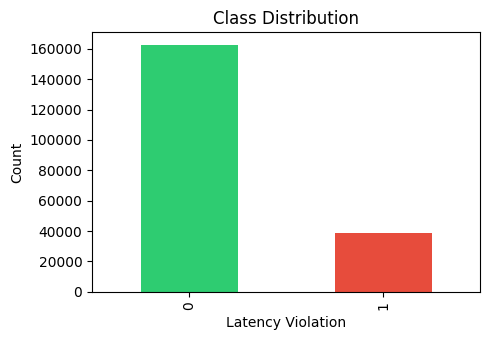

In [ ]:
# Cell 4 — Class Distribution
target_counts = df['latency_violation'].value_counts()
print("Overall violation rate:", round(df['latency_violation'].mean(), 4))
print("\nPer-node violation rate:")
print(df.groupby('node_type')['latency_violation'].mean().round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
target_counts.plot.bar(ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution')
ax.set_xlabel('Latency Violation')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Class imbalance ratio ~ 4:1. All models handle this via class weighting
# (pos_weight in BCEWithLogitsLoss for PyTorch models, class_weight='balanced'
# for Random Forest and meta-model). Router and camera have higher violation
# rates than phones and laptop — consistent with their role in the network topology.

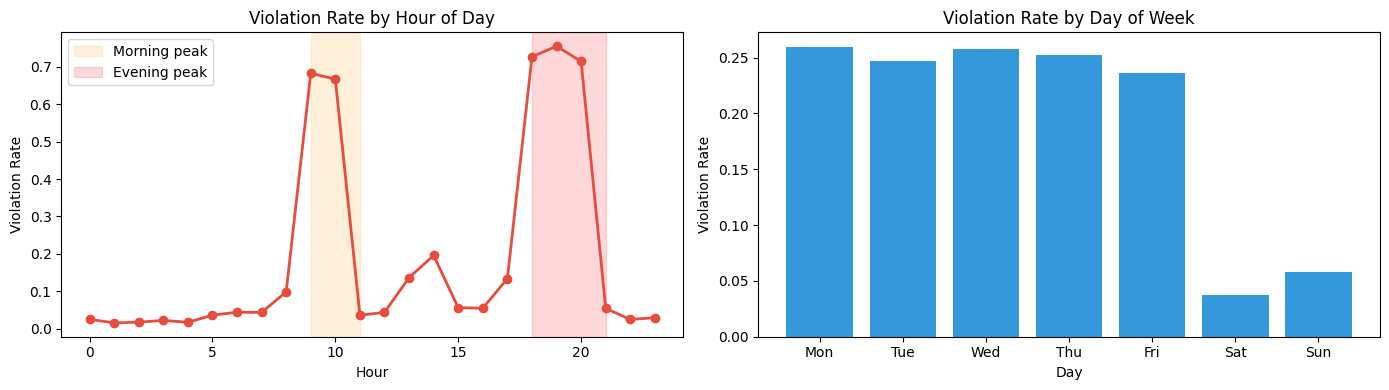

In [ ]:
# Cell 5 — Temporal Violation Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Violation rate by hour of day
hourly = df.groupby('hour_of_day')['latency_violation'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='#e74c3c')
axes[0].set_title('Violation Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Violation Rate')
axes[0].axvspan(9, 11, alpha=0.15, color='orange', label='Morning peak')
axes[0].axvspan(18, 21, alpha=0.15, color='red', label='Evening peak')
axes[0].legend()

# Violation rate by day of week
daily = df.groupby('day_of_week')['latency_violation'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_labels, daily.values, color='#3498db')
axes[1].set_title('Violation Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Violation Rate')

plt.tight_layout()
plt.show()

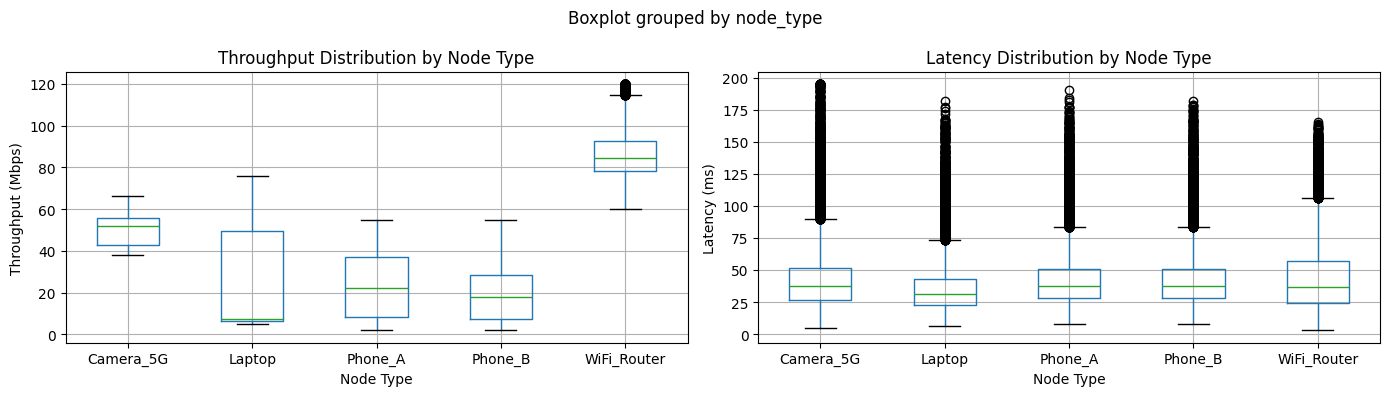

In [ ]:
# Cell 6 — Node-Type Behavior
# Expected: Camera has tightest throughput distribution, Phones the widest.
# Router has highest throughput. Camera has highest median latency (most sensitive to cascade).
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.boxplot(column='throughput', by='node_type', ax=axes[0])
axes[0].set_title('Throughput Distribution by Node Type')
axes[0].set_xlabel('Node Type')
axes[0].set_ylabel('Throughput (Mbps)')

df.boxplot(column='end_to_end_latency', by='node_type', ax=axes[1])
axes[1].set_title('Latency Distribution by Node Type')
axes[1].set_xlabel('Node Type')
axes[1].set_ylabel('Latency (ms)')

plt.tight_layout()
plt.show()

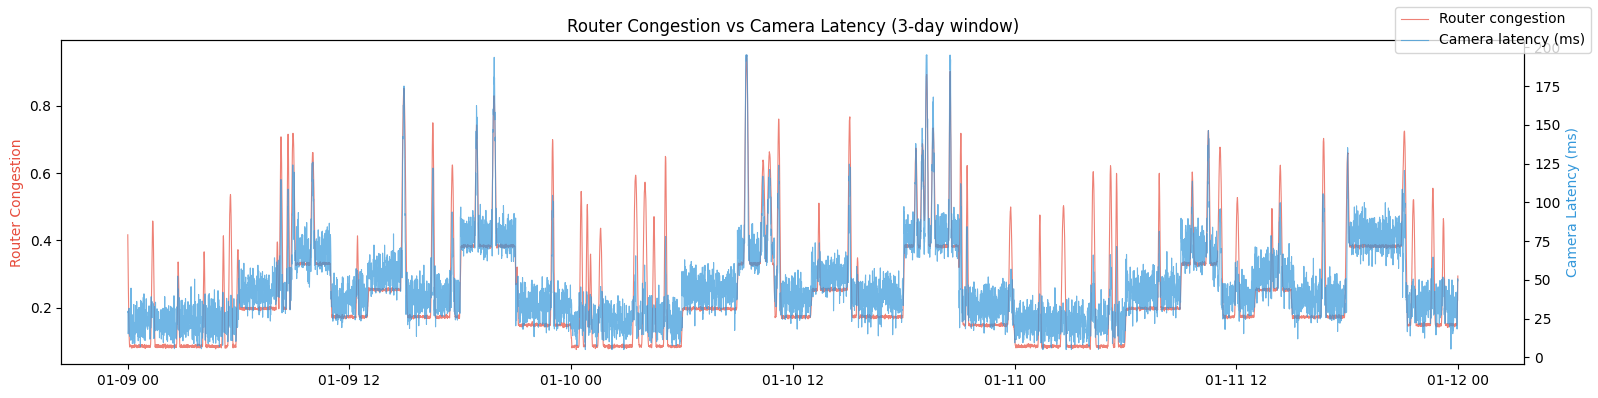

In [ ]:
# Cell 7 — Router Cascade Visualization (3-day window)
start = pd.Timestamp('2024-01-09')
end   = pd.Timestamp('2024-01-12')

router_slice = df[(df['node_id'] == 1) &
                  (df['timestamp'] >= start) &
                  (df['timestamp'] < end)].set_index('timestamp')

camera_slice = df[(df['node_id'] == 4) &
                  (df['timestamp'] >= start) &
                  (df['timestamp'] < end)].set_index('timestamp')

fig, ax1 = plt.subplots(figsize=(16, 4))
ax2 = ax1.twinx()

ax1.plot(router_slice.index, router_slice['network_congestion'],
         color='#e74c3c', alpha=0.7, linewidth=0.8, label='Router congestion')
ax2.plot(camera_slice.index, camera_slice['end_to_end_latency'],
         color='#3498db', alpha=0.7, linewidth=0.8, label='Camera latency (ms)')

ax1.set_ylabel('Router Congestion', color='#e74c3c')
ax2.set_ylabel('Camera Latency (ms)', color='#3498db')
ax1.set_title('Router Congestion vs Camera Latency (3-day window)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

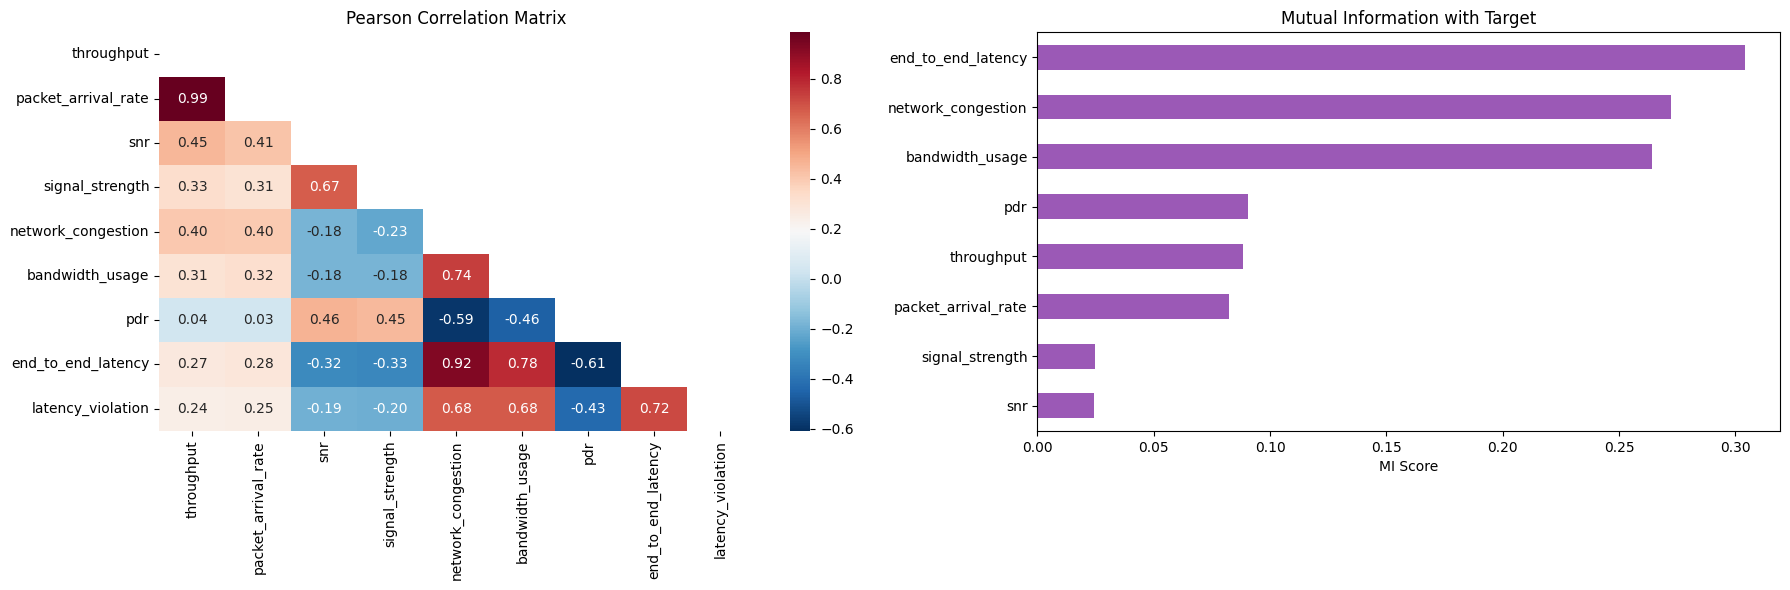

In [ ]:
# Cell 8 — Correlation Analysis (Pearson + Mutual Information)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in
                ['latency_violation', 'node_id', 'hour_of_day', 'day_of_week']]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pearson correlation heatmap
corr = df[numeric_cols + ['latency_violation']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix')

# Mutual information (nonlinear relationships)
mi_scores = mutual_info_classif(
    df[numeric_cols], df['latency_violation'],
    random_state=SEED
)
mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=True)
mi_series.plot.barh(ax=axes[1], color='#9b59b6')
axes[1].set_title('Mutual Information with Target')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 9 — Leakage Investigation
print("=== Leakage Investigation ===\n")

# Method 1: Pearson correlation with target
corr_with_target = df[numeric_cols].corrwith(df['latency_violation']).abs().sort_values(ascending=False)
print("Absolute Pearson correlation with target:")
print(corr_with_target.round(4))

# Method 2: Mutual information (already computed — reuse)
print("\nMutual Information with target:")
print(mi_series.sort_values(ascending=False).round(4))

# Method 3: Single-feature AUC test
# Any single feature achieving AUC > 0.90 on its own is almost certainly leakage
print("\nSingle-feature AUC test (AUC > 0.90 = leakage red flag):")
sample = df.sample(10000, random_state=SEED)
for col in numeric_cols:
    auc = roc_auc_score(sample['latency_violation'], sample[col])
    auc = max(auc, 1 - auc)   # flip if inverted
    flag = " <- LEAKAGE RISK" if auc > 0.90 else ""
    print(f"  {col:35s}: AUC = {auc:.3f}{flag}")

print("\nConclusion: end_to_end_latency at time t is NOT leakage because")
print("the target is defined as mean(latency[t+1:t+11]) > threshold,")
print("i.e., whether latency will be high in the NEXT 5 minutes, not NOW.")

=== Leakage Investigation ===

Absolute Pearson correlation with target:
end_to_end_latency     0.7173
bandwidth_usage        0.6808
network_congestion     0.6792
pdr                    0.4299
packet_arrival_rate    0.2499
throughput             0.2434
signal_strength        0.2026
snr                    0.1949
dtype: float64

Mutual Information with target:
end_to_end_latency     0.3039
network_congestion     0.2723
bandwidth_usage        0.2642
pdr                    0.0905
throughput             0.0884
packet_arrival_rate    0.0826
signal_strength        0.0247
snr                    0.0241
dtype: float64

Single-feature AUC test (AUC > 0.90 = leakage red flag):
  throughput                         : AUC = 0.670
  packet_arrival_rate                : AUC = 0.669
  snr                                : AUC = 0.627
  signal_strength                    : AUC = 0.644
  network_congestion                 : AUC = 0.946 <- LEAKAGE RISK
  bandwidth_usage                    : AUC = 0.925 <- L

In [ ]:
# Cell 10 — Feature Engineering
df_fe = df.sort_values(['node_id', 'timestamp']).reset_index(drop=True)

WINDOW_SHORT = 5    # 2.5-min window
WINDOW_LONG  = 20   # 10-min window

for col in ['throughput', 'network_congestion', 'end_to_end_latency']:
    grp = df_fe.groupby('node_id')[col]

    df_fe[f'{col}_roll_mean_short'] = grp.transform(
        lambda x: x.rolling(WINDOW_SHORT, min_periods=1).mean().shift(1)
    ).ffill().bfill()

    df_fe[f'{col}_roll_std_short'] = grp.transform(
        lambda x: x.rolling(WINDOW_SHORT, min_periods=1).std().shift(1)
    ).fillna(0)

    df_fe[f'{col}_roll_mean_long'] = grp.transform(
        lambda x: x.rolling(WINDOW_LONG, min_periods=1).mean().shift(1)
    ).ffill().bfill()

# lag: direct past values
for col in ['end_to_end_latency', 'network_congestion', 'throughput']:
    for lag in [1, 2, 5]:
        df_fe[f'{col}_lag{lag}'] = df_fe.groupby('node_id')[col].shift(lag)

df_fe.fillna(0, inplace=True)

# rate of change signal
df_fe['congestion_trend'] = df_fe.groupby('node_id')['network_congestion'].diff(10).fillna(0)

df_fe = pd.get_dummies(df_fe, columns=['node_type'], prefix='node', dtype=float)
df_fe.drop(columns=['node_WiFi_Router'], inplace=True, errors='ignore')

print(f"Features after engineering: {df_fe.shape[1]}")
eng_features = [c for c in df_fe.columns if any(x in c for x in ['roll', 'lag', 'trend', 'node_'])]
print(f"New features created ({len(eng_features)}):")
for f in eng_features:
    print(f"  {f}")

Features after engineering: 36
New features created (24):
  node_id
  throughput_roll_mean_short
  throughput_roll_std_short
  throughput_roll_mean_long
  network_congestion_roll_mean_short
  network_congestion_roll_std_short
  network_congestion_roll_mean_long
  end_to_end_latency_roll_mean_short
  end_to_end_latency_roll_std_short
  end_to_end_latency_roll_mean_long
  end_to_end_latency_lag1
  end_to_end_latency_lag2
  end_to_end_latency_lag5
  network_congestion_lag1
  network_congestion_lag2
  network_congestion_lag5
  throughput_lag1
  throughput_lag2
  throughput_lag5
  congestion_trend
  node_Camera_5G
  node_Laptop
  node_Phone_A
  node_Phone_B


In [ ]:
# Cell 11 — Chronological Split then Feature Selection
exclude = ['timestamp', 'latency_violation', 'node_id']
feature_cols = [c for c in df_fe.columns if c not in exclude]

# CHRONOLOGICAL SPLIT — no random shuffle
df_fe_sorted = df_fe.sort_values('timestamp').reset_index(drop=True)
X_all = df_fe_sorted[feature_cols].values
y_all = df_fe_sorted['latency_violation'].values

n         = len(X_all)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train_raw = X_all[:train_end]
X_val_raw   = X_all[train_end:val_end]
X_test_raw  = X_all[val_end:]
y_train     = y_all[:train_end]
y_val       = y_all[train_end:val_end]
y_test      = y_all[val_end:]

dates = df_fe_sorted['timestamp']
print(f"Train : {dates.iloc[0]} -> {dates.iloc[train_end-1]}  ({train_end:,} rows)")
print(f"Val   : {dates.iloc[train_end]} -> {dates.iloc[val_end-1]}  ({val_end-train_end:,} rows)")
print(f"Test  : {dates.iloc[val_end]} -> {dates.iloc[len(dates)-1]}  ({n-val_end:,} rows)")

# Feature selection — FIT ONLY ON TRAINING DATA
N_BEST   = 18
selector = SelectKBest(mutual_info_classif, k=N_BEST)
selector.fit(X_train_raw, y_train)     # FIT on train only

X_train_sel = selector.transform(X_train_raw)
X_val_sel   = selector.transform(X_val_raw)
X_test_sel  = selector.transform(X_test_raw)

selected_features = [feature_cols[i] for i in selector.get_support(indices=True)]
print(f"\nSelected {N_BEST} features:")
for f in selected_features:
    print(f"  {f}")

Train : 2024-01-08 00:00:00 -> 2024-01-17 19:11:30  (141,120 rows)
Val   : 2024-01-17 19:12:00 -> 2024-01-19 21:35:30  (30,240 rows)
Test  : 2024-01-19 21:36:00 -> 2024-01-21 23:59:30  (30,240 rows)

Selected 18 features:
  hour_of_day
  throughput
  network_congestion
  bandwidth_usage
  pdr
  end_to_end_latency
  throughput_roll_mean_short
  throughput_roll_mean_long
  network_congestion_roll_mean_short
  network_congestion_roll_mean_long
  end_to_end_latency_roll_mean_short
  end_to_end_latency_roll_mean_long
  end_to_end_latency_lag1
  end_to_end_latency_lag2
  end_to_end_latency_lag5
  network_congestion_lag1
  network_congestion_lag2
  network_congestion_lag5


=== KS Test: Train vs Test Distribution ===
Feature                                   KS Stat     p-value     Shift?
---------------------------------------------------------------------------
hour_of_day                                   0.0539      0.0000  YES
throughput                                    0.1131      0.0000  YES
network_congestion                            0.2104      0.0000  YES
bandwidth_usage                               0.1981      0.0000  YES
pdr                                           0.1087      0.0000  YES
end_to_end_latency                            0.2031      0.0000  YES
throughput_roll_mean_short                    0.1323      0.0000  YES
throughput_roll_mean_long                     0.1419      0.0000  YES
network_congestion_roll_mean_short            0.2465      0.0000  YES


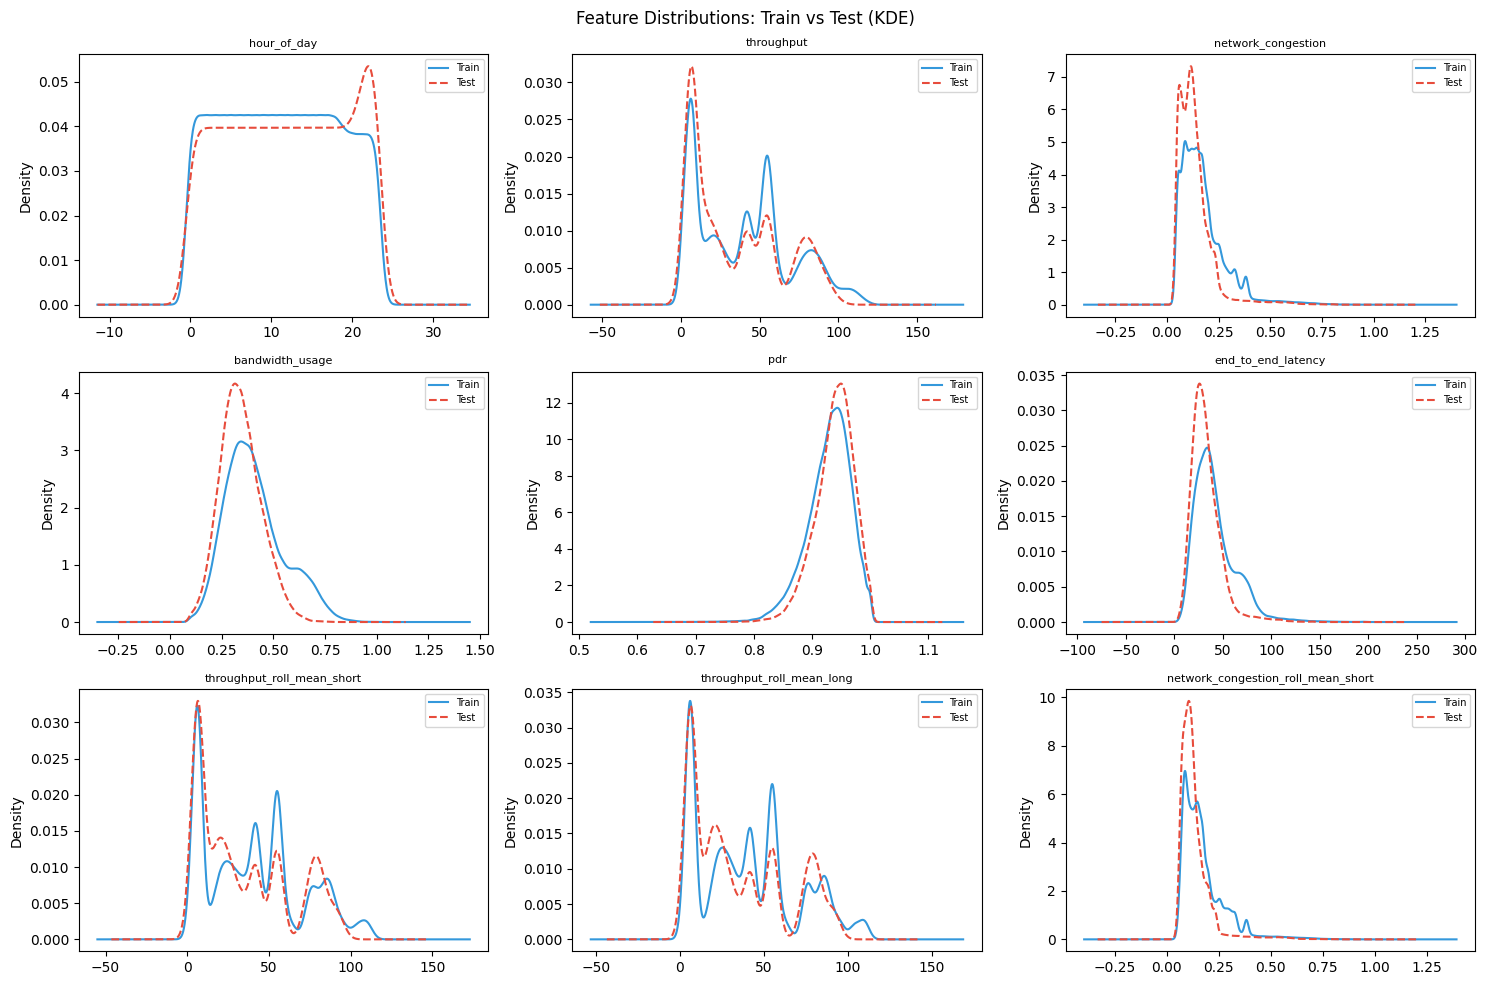

In [ ]:
# Cell 12 — Feature Distribution Analysis (Train vs Test)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes_flat = axes.ravel()

print("=== KS Test: Train vs Test Distribution ===")
print(f"{'Feature':40s}  {'KS Stat':10s}  {'p-value':10s}  {'Shift?'}")
print("-" * 75)

for i, feat in enumerate(selected_features[:9]):
    feat_idx = list(feature_cols).index(feat)
    tr_vals  = X_train_raw[:, feat_idx]
    te_vals  = X_test_raw[:, feat_idx]

    stat, pval = ks_2samp(tr_vals, te_vals)
    shift      = "YES" if pval < 0.05 else "no"
    print(f"{feat:40s}  {stat:10.4f}  {pval:10.4f}  {shift}")

    pd.Series(tr_vals).plot.kde(ax=axes_flat[i], label='Train', color='#3498db')
    pd.Series(te_vals).plot.kde(ax=axes_flat[i], label='Test',  color='#e74c3c', linestyle='--')
    axes_flat[i].set_title(feat, fontsize=8)
    axes_flat[i].legend(fontsize=7)

plt.suptitle('Feature Distributions: Train vs Test (KDE)')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13 — Scaling (Fitted on Training Data Only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel)   # fit on train only
X_val_sc   = scaler.transform(X_val_sel)
X_test_sc  = scaler.transform(X_test_sel)

# noise on train only
rng = np.random.default_rng(SEED)
X_train_sc = X_train_sc + rng.normal(0, 0.08, X_train_sc.shape)

print(f"X_train_sc: {X_train_sc.shape}")
print(f"X_val_sc  : {X_val_sc.shape}")
print(f"X_test_sc : {X_test_sc.shape}")
print(f"\nPost-scaling train stats (should be near 0 mean, 1 std):")
print(f"  mean: {X_train_sc.mean(axis=0).mean():.4f}")
print(f"  std : {X_train_sc.std(axis=0).mean():.4f}")

X_train_sc: (141120, 18)
X_val_sc  : (30240, 18)
X_test_sc : (30240, 18)

Post-scaling train stats (should be near 0 mean, 1 std):
  mean: 0.0000
  std : 1.0033


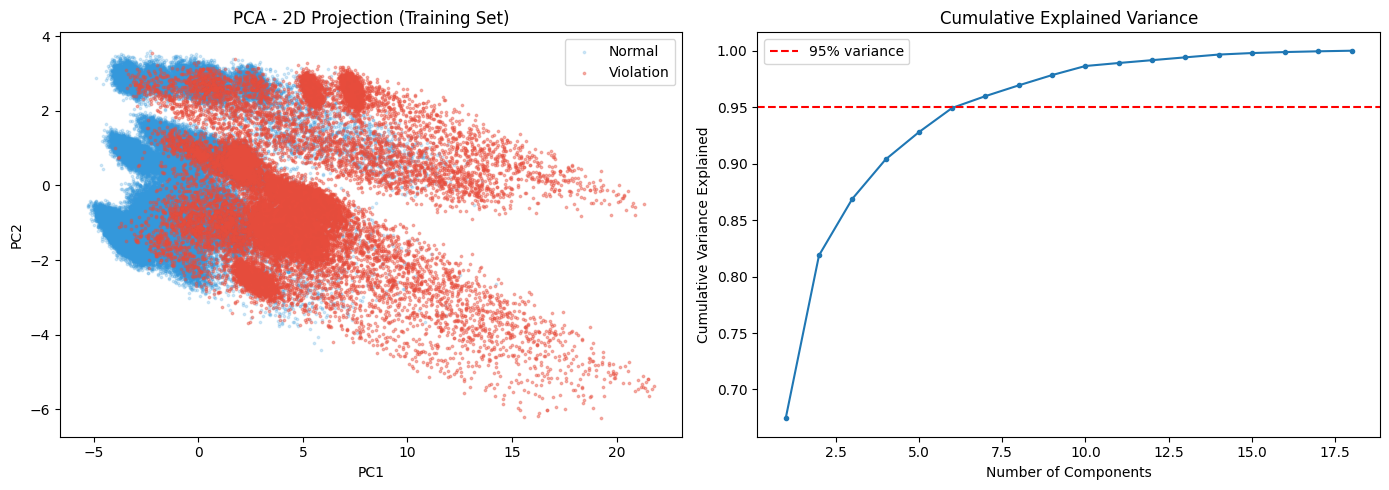

Variance explained by PC1: 67.45%
Variance explained by PC2: 14.43%
Components needed for 95% variance: 7


In [ ]:
# Cell 14 — PCA Visualization
pca_viz = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_viz.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca_2d[y_train==0, 0], X_pca_2d[y_train==0, 1],
                alpha=0.2, s=3, label='Normal', color='#3498db')
axes[0].scatter(X_pca_2d[y_train==1, 0], X_pca_2d[y_train==1, 1],
                alpha=0.4, s=3, label='Violation', color='#e74c3c')
axes[0].set_title('PCA - 2D Projection (Training Set)')
axes[0].legend()
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

pca_full = PCA(random_state=SEED).fit(X_train_sc)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Variance explained by PC1: {pca_full.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_full.explained_variance_ratio_[1]:.2%}")
print(f"Components needed for 95% variance: {(cumvar >= 0.95).argmax() + 1}")

In [ ]:
# Cell 15 — Class Imbalance Handling
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive class weight: {pos_weight:.2f}")
print(f"Used in BCEWithLogitsLoss for LSTM and TCN")
print(f"Used as class_weight='balanced' for Random Forest and meta-model")

Positive class weight: 3.79
Used in BCEWithLogitsLoss for LSTM and TCN
Used as class_weight='balanced' for Random Forest and meta-model


In [ ]:
# Cell 16 — Sequence Builder for LSTM and TCN
SEQ_LEN = 20   # 10-minute lookback (20 x 30 seconds)

def build_sequences_per_node(X_full, y_full, node_ids_full, seq_len):
    # Per-node only — sequences must not cross node boundaries
    all_X, all_y, all_flat_idx = [], [], []
    for nid in np.unique(node_ids_full):
        mask   = (node_ids_full == nid)
        indices = np.where(mask)[0]
        X_node = X_full[mask]
        y_node = y_full[mask]
        for i in range(seq_len, len(X_node)):
            all_X.append(X_node[i - seq_len : i])
            all_y.append(y_node[i])
            all_flat_idx.append(indices[i])
    return np.array(all_X), np.array(all_y), np.array(all_flat_idx)

# Get node_id arrays aligned with each split
df_sorted = df_fe.sort_values('timestamp').reset_index(drop=True)
node_ids_all = df_sorted['node_id'].values

node_ids_train = node_ids_all[:train_end]
node_ids_val   = node_ids_all[train_end:val_end]
node_ids_test  = node_ids_all[val_end:]

X_train_seq, y_train_seq, train_flat_idx = build_sequences_per_node(
    X_train_sc, y_train, node_ids_train, SEQ_LEN)
X_val_seq, y_val_seq, val_flat_idx = build_sequences_per_node(
    X_val_sc, y_val, node_ids_val, SEQ_LEN)
X_test_seq, y_test_seq, test_flat_idx = build_sequences_per_node(
    X_test_sc, y_test, node_ids_test, SEQ_LEN)

print(f"Sequence shapes - Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")

Sequence shapes - Train: (141020, 20, 18), Val: (30140, 20, 18), Test: (30140, 20, 18)


In [ ]:
# Cell 17 — PyTorch Datasets and DataLoaders
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE = 256

train_loader = DataLoader(SeqDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val_seq,   y_val_seq),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SeqDataset(X_test_seq,  y_test_seq),  batch_size=BATCH_SIZE, shuffle=False)
print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batches - Train: 551, Val: 118, Test: 118


In [ ]:
# Cell 19 — LSTM Model Definition
# Key changes vs original: hidden_dim=64 (was 8), num_layers=2 (was 1),
# dropout=0.25 (was 0.60 — over-regularized)

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout      # active between layers since num_layers=2
        )
        self.bn   = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last    = h[-1]              # last layer's hidden state
        h_last    = self.bn(h_last)
        h_last    = self.drop(h_last)
        return self.fc(h_last).squeeze(-1)

print("LSTM architecture defined.")

LSTM architecture defined.


In [ ]:
# Cell 20 — TCN Model Definition
# Key: channels=32 (was 8), dropout=0.25 (was 0.60), 3 blocks with dilations 1,2,4

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.25):
        super().__init__()
        pad         = (kernel - 1) * dilation
        self.conv1  = nn.Conv1d(in_ch,  out_ch, kernel, padding=pad, dilation=dilation)
        self.conv2  = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation)
        self.bn1    = nn.BatchNorm1d(out_ch)
        self.bn2    = nn.BatchNorm1d(out_ch)
        self.drop   = nn.Dropout(dropout)
        self.skip   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu   = nn.ReLU()
        self._pad   = pad

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)[..., :-self._pad]))
        out = self.drop(out)
        out = self.relu(self.bn2(self.conv2(out)[..., :-self._pad]))
        out = self.drop(out)
        return self.relu(out + self.skip(x))

class TCNClassifier(nn.Module):
    def __init__(self, input_dim, channels=32, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            TCNBlock(input_dim, channels, dilation=1, dropout=dropout),
            TCNBlock(channels,  channels, dilation=2, dropout=dropout),
            TCNBlock(channels,  channels, dilation=4, dropout=dropout),
        )
        self.fc = nn.Linear(channels, 1)

    def forward(self, x):
        x   = x.transpose(1, 2)        # (batch, features, seq_len)
        out = self.net(x)
        out = out[:, :, -1]            # last timestep
        return self.fc(out).squeeze(-1)

print("TCN architecture defined.")

TCN architecture defined.


In [ ]:
# Cell 21 — Generic PyTorch Training Loop
# WHY gradient clipping: LSTM is susceptible to exploding gradients —
# loss can spike to NaN if gradient norms grow unchecked. Clipping at norm=1.0 is standard.

def train_pytorch_model(model, train_loader, val_loader,
                        epochs=60, lr=1e-3, pos_weight_val=None,
                        patience=10, model_name='model'):
    pos_w     = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE) if pos_weight_val else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Train
        model.train()
        tr_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        # Validate
        model.eval()
        vl_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                vl_loss += criterion(model(X_batch), y_batch).item()
        vl_loss /= len(val_loader)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        scheduler.step(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}: train={tr_loss:.4f}  val={vl_loss:.4f}")

    model.load_state_dict(torch.load(f'best_{model_name}.pt', weights_only=True))
    return train_losses, val_losses

print("Training loop defined.")


Training loop defined.


In [ ]:
# Cell 22 — Train LSTM
input_dim  = X_train_seq.shape[2]
lstm_model = LSTMClassifier(input_dim=input_dim).to(DEVICE)

print(f"LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

lstm_train_loss, lstm_val_loss = train_pytorch_model(
    lstm_model, train_loader, val_loader,
    epochs=100, lr=5e-4, pos_weight_val=pos_weight,
    patience=15, model_name='lstm'
)

LSTM parameters: 54,977
  Epoch  10: train=0.2815  val=0.2880
  Epoch  20: train=0.2457  val=0.3096
  Early stopping at epoch 23


In [ ]:
# Cell 23 — Train TCN
tcn_model = TCNClassifier(input_dim=input_dim).to(DEVICE)

print(f"TCN parameters: {sum(p.numel() for p in tcn_model.parameters()):,}")

tcn_train_loss, tcn_val_loss = train_pytorch_model(
    tcn_model, train_loader, val_loader,
    epochs=100, lr=5e-4, pos_weight_val=pos_weight,
    patience=15, model_name='tcn'
)

TCN parameters: 18,305
  Epoch  10: train=0.2964  val=0.2866
  Epoch  20: train=0.2750  val=0.2828
  Early stopping at epoch 30


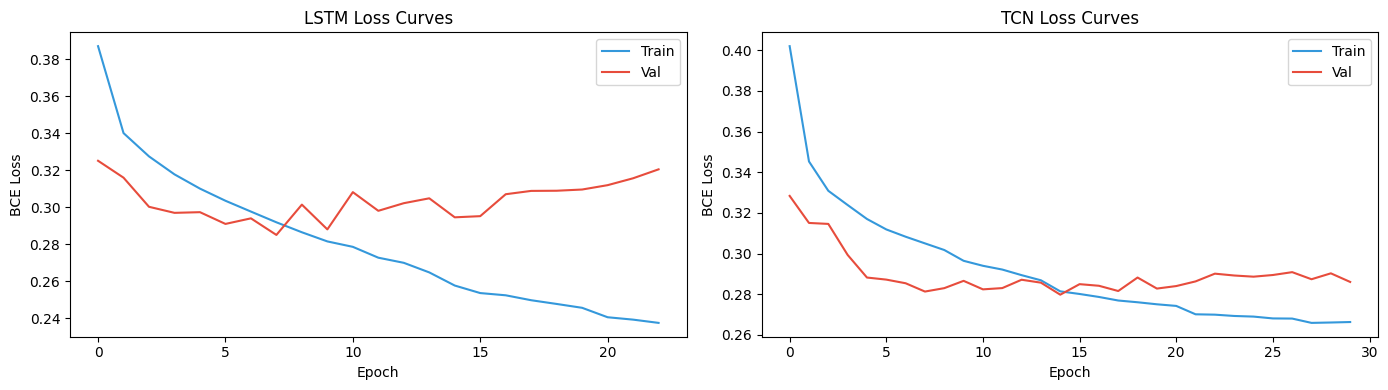

LSTM best val loss: 0.2850 at epoch 8
TCN  best val loss: 0.2798 at epoch 15


In [ ]:
# Cell 24 — Loss Curves (LSTM and TCN)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, train_loss, val_loss, title in [
    (axes[0], lstm_train_loss, lstm_val_loss, 'LSTM'),
    (axes[1], tcn_train_loss,  tcn_val_loss,  'TCN'),
]:
    ax.plot(train_loss, label='Train', color='#3498db')
    ax.plot(val_loss,   label='Val',   color='#e74c3c')
    ax.set_title(f'{title} Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"LSTM best val loss: {min(lstm_val_loss):.4f} at epoch {lstm_val_loss.index(min(lstm_val_loss))+1}")
print(f"TCN  best val loss: {min(tcn_val_loss):.4f} at epoch {tcn_val_loss.index(min(tcn_val_loss))+1}")

In [ ]:
# Cell 25 — Train Random Forest with Optuna

def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 250),
        'max_depth':        trial.suggest_int('max_depth', 4, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 60),
        'max_features':     trial.suggest_float('max_features', 0.3, 0.6),
        'class_weight':     'balanced',
        'random_state':     SEED,
        'n_jobs':           -1,
    }
    rf = RandomForestClassifier(**params)
    rf.fit(X_train_sel, y_train)
    proba = rf.predict_proba(X_val_sel)[:, 1]
    return roc_auc_score(y_val, proba)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage='sqlite:///rf_optuna_study.db',
    study_name='rf_5g_latency',
    load_if_exists=True
)
study.optimize(rf_objective, n_trials=25, show_progress_bar=True)

# Export trial history for reproducibility documentation
study.trials_dataframe().to_csv('optuna_rf_trials.csv', index=False)

best_rf_params = study.best_params
best_rf_params.update({'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1})

rf_model = RandomForestClassifier(**best_rf_params)
rf_model.fit(X_train_sel, y_train)

rf_val_proba = rf_model.predict_proba(X_val_sel)[:, 1]
print(f"Best RF AUC (val): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")
print(f"RF Validation F1: {f1_score(y_val, (rf_val_proba >= 0.5).astype(int), zero_division=0):.4f}")

[I 2026-04-08 13:49:16,240] A new study created in RDB with name: rf_5g_latency


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-08 13:50:28,814] Trial 0 finished with value: 0.983624301757721 and parameters: {'n_estimators': 156, 'max_depth': 8, 'min_samples_leaf': 50, 'max_features': 0.47959754525911097}. Best is trial 0 with value: 0.983624301757721.
[I 2026-04-08 13:51:05,189] Trial 1 finished with value: 0.9779998952569049 and parameters: {'n_estimators': 123, 'max_depth': 4, 'min_samples_leaf': 22, 'max_features': 0.5598528437324806}. Best is trial 0 with value: 0.983624301757721.
[I 2026-04-08 13:52:44,985] Trial 2 finished with value: 0.982809588218493 and parameters: {'n_estimators': 190, 'max_depth': 7, 'min_samples_leaf': 20, 'max_features': 0.5909729556485983}. Best is trial 0 with value: 0.983624301757721.
[I 2026-04-08 13:53:36,569] Trial 3 finished with value: 0.9796713670196252 and parameters: {'n_estimators': 225, 'max_depth': 5, 'min_samples_leaf': 27, 'max_features': 0.35502135295603016}. Best is trial 0 with value: 0.983624301757721.
[I 2026-04-08 13:54:15,195] Trial 4 finished wit

In [ ]:
# Cell 26 — Inference Functions

def predict_proba_pytorch(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in loader:
            logits = model(X_batch.to(DEVICE))
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs)

def evaluate_model(name, y_true, y_proba, threshold=0.50):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':    round(average_precision_score(y_true, y_proba), 4),
        'MCC':       round(matthews_corrcoef(y_true, y_pred), 4),
    }

print("Inference functions defined.")

Inference functions defined.


In [ ]:
# Cell 27 — Stacking Ensemble
# Generate base model probabilities for val (train meta) and test (evaluate)

# LSTM & TCN on sequence loaders
lstm_val_probs  = predict_proba_pytorch(lstm_model, val_loader)
lstm_test_probs = predict_proba_pytorch(lstm_model, test_loader)
tcn_val_probs   = predict_proba_pytorch(tcn_model,  val_loader)
tcn_test_probs  = predict_proba_pytorch(tcn_model,  test_loader)

# RF on flat features — use flat indices from sequence builder for alignment
rf_val_all   = rf_model.predict_proba(X_val_sel)[:, 1]
rf_test_all  = rf_model.predict_proba(X_test_sel)[:, 1]

# Align RF predictions with sequence indices
# val_flat_idx maps into the val split (0-indexed within val)
rf_val_probs  = rf_val_all[val_flat_idx - val_flat_idx.min()]
rf_test_probs = rf_test_all[test_flat_idx - test_flat_idx.min()]

# Stack for meta-model
meta_val_X  = np.column_stack([lstm_val_probs, tcn_val_probs, rf_val_probs])
meta_test_X = np.column_stack([lstm_test_probs, tcn_test_probs, rf_test_probs])

# Meta-model: Logistic Regression trained on val predictions
meta_model = LogisticRegression(C=1.0, class_weight='balanced', random_state=SEED, max_iter=1000)
meta_model.fit(meta_val_X, y_val_seq)

ensemble_test_probs = meta_model.predict_proba(meta_test_X)[:, 1]

print("Meta-model coefficients (higher = more trusted by ensemble):")
for name, coef in zip(['LSTM', 'TCN', 'RF'], meta_model.coef_[0]):
    print(f"  {name}: {coef:.4f}")
print(f"  Intercept: {meta_model.intercept_[0]:.4f}")

Meta-model coefficients (higher = more trusted by ensemble):
  LSTM: 3.4836
  TCN: 3.9086
  RF: 0.2041
  Intercept: -3.8946


In [ ]:
# Cell 28 — Model Comparison Table
results = [
    evaluate_model('LSTM',          y_test_seq, lstm_test_probs),
    evaluate_model('TCN',           y_test_seq, tcn_test_probs),
    evaluate_model('Random Forest', y_test_seq, rf_test_probs),
    evaluate_model('Ensemble',      y_test_seq, ensemble_test_probs),
]
df_results = pd.DataFrame(results).set_index('Model')
print("\n=== Test Set Performance (threshold=0.50) ===")
print(df_results.to_string())


=== Test Set Performance (threshold=0.50) ===
               Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC     MCC
Model                                                                      
LSTM             0.9687     0.7012  0.5833  0.6369   0.9418  0.6619  0.6235
TCN              0.9671     0.6628  0.6095  0.6350   0.9413  0.6767  0.6184
Random Forest    0.9079     0.0838  0.0968  0.0898   0.6922  0.0877  0.0417
Ensemble         0.9697     0.7147  0.5925  0.6479   0.9438  0.6856  0.6352


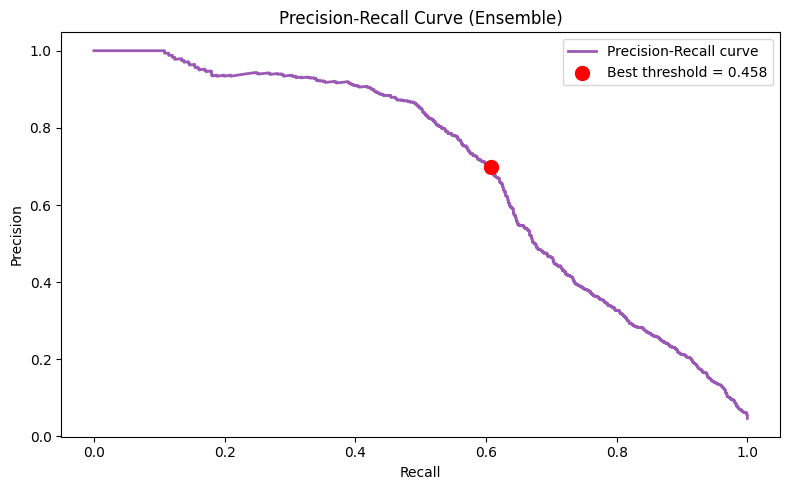

Default threshold 0.50 -> F1 = 0.6476
Optimal threshold 0.458 -> F1 = 0.6501

Ensemble with optimized threshold:
                      Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC     MCC
Model                                                                             
Ensemble (optimized)    0.9692     0.6983  0.6081  0.6501   0.9438  0.6856  0.6357


In [ ]:
# Cell 29 — Threshold Optimization (Precision-Recall Curve)
prec, rec, thresholds = precision_recall_curve(y_test_seq, ensemble_test_probs)
f1_arr  = 2 * prec * rec / (prec + rec + 1e-9)
best_i  = np.argmax(f1_arr)
best_thr = thresholds[best_i]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, linewidth=2, color='#9b59b6', label='Precision-Recall curve')
ax.scatter(rec[best_i], prec[best_i], s=100, color='red',
           zorder=5, label=f'Best threshold = {best_thr:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Ensemble)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Default threshold 0.50 -> F1 = {f1_arr[np.argmin(np.abs(thresholds - 0.50))]:.4f}")
print(f"Optimal threshold {best_thr:.3f} -> F1 = {f1_arr[best_i]:.4f}")

# Re-evaluate ensemble with optimized threshold
ensemble_opt = evaluate_model('Ensemble (optimized)', y_test_seq, ensemble_test_probs, threshold=best_thr)
print(f"\nEnsemble with optimized threshold:")
print(pd.DataFrame([ensemble_opt]).set_index('Model').to_string())

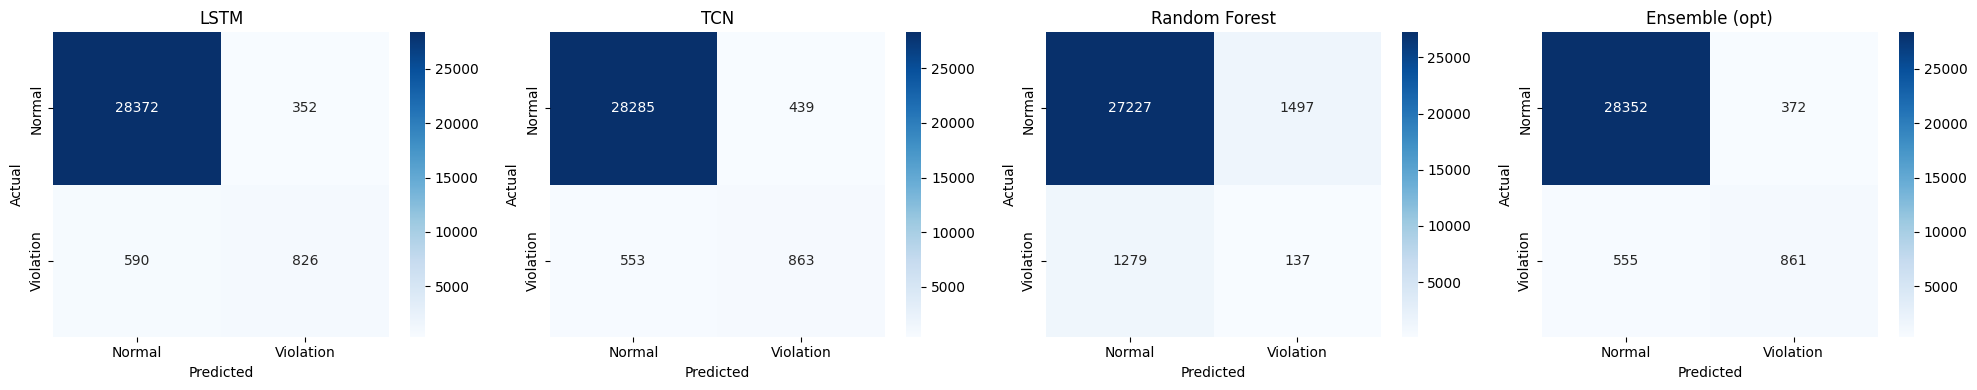

In [ ]:
# Cell 30 — Confusion Matrices (All Models)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models_for_cm = [
    ('LSTM', (lstm_test_probs >= 0.5).astype(int)),
    ('TCN', (tcn_test_probs >= 0.5).astype(int)),
    ('Random Forest', (rf_test_probs >= 0.5).astype(int)),
    ('Ensemble (opt)', (ensemble_test_probs >= best_thr).astype(int)),
]

for ax, (name, preds) in zip(axes, models_for_cm):
    cm = confusion_matrix(y_test_seq, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Violation'],
                yticklabels=['Normal', 'Violation'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Top 10 features (impurity vs permutation):
                               feature  impurity  permutation
5                   end_to_end_latency  0.442354     0.002119
10  end_to_end_latency_roll_mean_short  0.249285     0.002340
12             end_to_end_latency_lag1  0.119938     0.023837
2                   network_congestion  0.045623     0.000731
8   network_congestion_roll_mean_short  0.036685    -0.000004
13             end_to_end_latency_lag2  0.025281     0.063998
11   end_to_end_latency_roll_mean_long  0.018245     0.001308
3                      bandwidth_usage  0.013927     0.003413
15             network_congestion_lag1  0.011251     0.000562
7            throughput_roll_mean_long  0.009111     0.005654


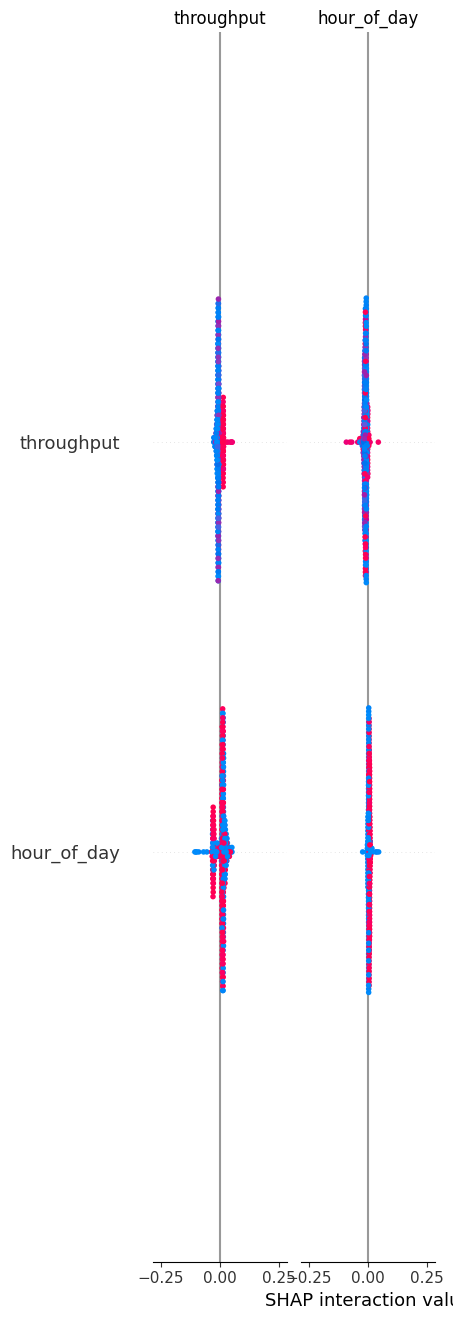

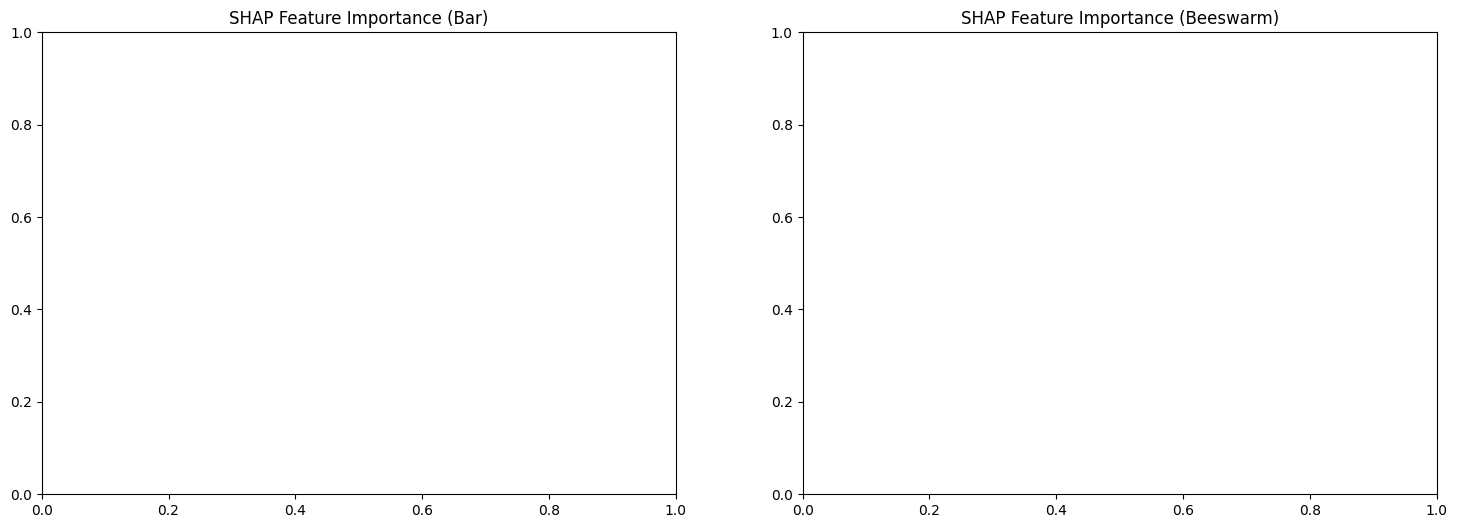

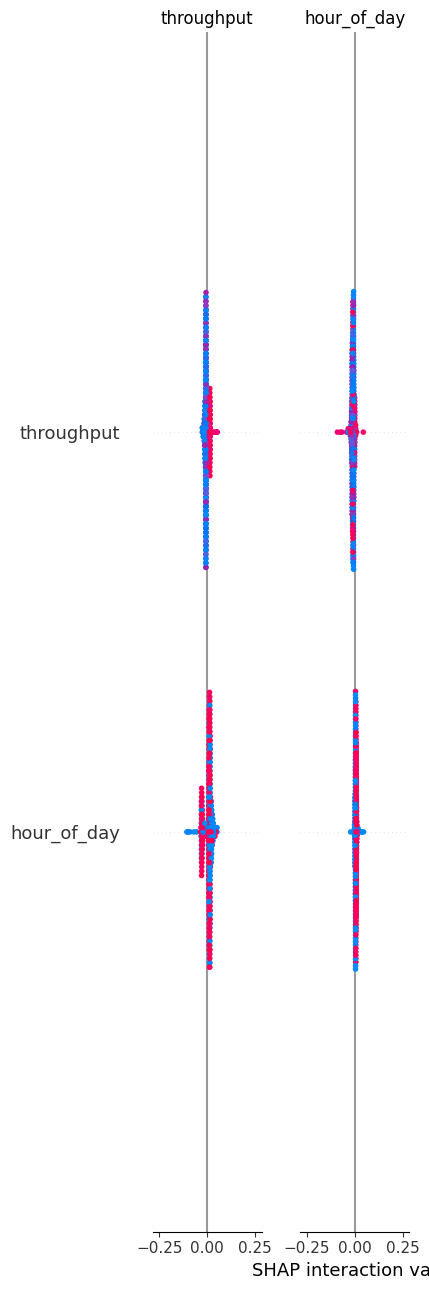

In [ ]:
# Cell 31 — Feature Importance: Impurity + Permutation + SHAP

# --- Impurity-based (fast, built-in) ---
importances = rf_model.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature': selected_features,
    'impurity': importances
}).sort_values('impurity', ascending=False)

# --- Permutation importance (model-agnostic, more reliable) ---
# Use aligned test features for permutation importance
X_test_aligned = X_test_sel[test_flat_idx - test_flat_idx.min()]
perm_result = permutation_importance(
    rf_model, X_test_aligned, y_test_seq,
    n_repeats=10, random_state=SEED, scoring='roc_auc'
)
feat_importance_df['permutation'] = perm_result.importances_mean

print("Top 10 features (impurity vs permutation):")
print(feat_importance_df.head(10).to_string())

# --- SHAP (gold standard — local + global) ---
explainer   = shap.TreeExplainer(rf_model)
shap_sample = X_test_aligned[:500]
shap_values = explainer.shap_values(shap_sample)

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
plt.sca(axes[0])
shap.summary_plot(shap_vals, shap_sample, feature_names=selected_features,
                  plot_type='bar', show=False, max_display=15)
axes[0].set_title('SHAP Feature Importance (Bar)')

# Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(shap_vals, shap_sample, feature_names=selected_features,
                  show=False, max_display=15)
axes[1].set_title('SHAP Feature Importance (Beeswarm)')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 32 — Save All Models
import joblib
from google.colab import files
torch.save(lstm_model.state_dict(), 'lstm_model.pt')
torch.save(tcn_model.state_dict(),  'tcn_model.pt')
joblib.dump(rf_model,               'rf_model.pkl')
joblib.dump(meta_model,             'meta_model.pkl')
joblib.dump(scaler,                 'scaler.pkl')
joblib.dump(selector,               'selector.pkl')

print("All models and preprocessing objects saved")
print("Files: lstm_model.pt, tcn_model.pt, rf_model.pkl,")
print("       meta_model.pkl, scaler.pkl, selector.pkl")
for fname in ['lstm_model.pt', 'tcn_model.pt', 'rf_model.pkl',
              'meta_model.pkl', 'scaler.pkl', 'selector.pkl']:
    files.download(fname)

All models and preprocessing objects saved
Files: lstm_model.pt, tcn_model.pt, rf_model.pkl,
       meta_model.pkl, scaler.pkl, selector.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 33 — Simulated Live Feed (Real-Time Implementation)
import time

buffers = {nid: [] for nid in range(1, 6)}

print("=" * 70)
print("   5G CAMPUS NETWORK - LIVE LATENCY VIOLATION MONITOR")
print("=" * 70)
print(f"{'Timestamp':22} {'Node':14} {'Latency':10} {'P(Viol)':10} {'Status'}")
print("-" * 70)

test_df = df_fe.sort_values('timestamp').iloc[val_end:].reset_index(drop=True)

display_count = 0
max_display = 50  # Show first 50 predictions

for _, row in test_df.iterrows():
    nid     = int(row['node_id'])
    ts      = row['timestamp']
    latency = row.get('end_to_end_latency', 0)

    # Preprocess current row
    feat_raw = row[feature_cols].values.astype(float).reshape(1, -1)
    feat_sel = selector.transform(feat_raw)[0]
    feat_sc  = scaler.transform([feat_sel])[0]

    # Update this node's rolling buffer
    buffers[nid].append(feat_sc)
    if len(buffers[nid]) > SEQ_LEN:
        buffers[nid].pop(0)

    if len(buffers[nid]) < SEQ_LEN:
        continue

    # LSTM prediction
    seq_t = torch.tensor([buffers[nid]], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        lstm_model.eval()
        lstm_p = torch.sigmoid(lstm_model(seq_t)).item()

    # TCN prediction
    with torch.no_grad():
        tcn_model.eval()
        tcn_p = torch.sigmoid(tcn_model(seq_t)).item()

    # RF prediction (flat features, unscaled)
    rf_p = rf_model.predict_proba([feat_sel])[0][1]

    # Ensemble via meta-model
    meta_in = np.array([[lstm_p, tcn_p, rf_p]])
    p_viol  = meta_model.predict_proba(meta_in)[0][1]

    if display_count < max_display:
        status = "ALERT" if p_viol >= best_thr else "OK"
        node_labels = {1: 'WiFi_Router', 2: 'Phone_A', 3: 'Phone_B', 4: 'Camera_5G', 5: 'Laptop'}
        node_label = node_labels.get(nid, f'Node_{nid}')
        print(f"{str(ts):22} {node_label:14} {latency:8.1f}ms  {p_viol:8.3f}   {status}")
        display_count += 1

    if display_count >= max_display:
        break

print(f"\n... (showing first {max_display} predictions)")
print("In production, this loop runs continuously at 30-second intervals.")

   5G CAMPUS NETWORK - LIVE LATENCY VIOLATION MONITOR
Timestamp              Node           Latency    P(Viol)    Status
----------------------------------------------------------------------
2024-01-19 21:45:30    Camera_5G          48.0ms     0.044   OK
2024-01-19 21:45:30    WiFi_Router        30.0ms     0.038   OK
2024-01-19 21:45:30    Laptop             37.3ms     0.025   OK
2024-01-19 21:45:30    Phone_B            27.1ms     0.021   OK
2024-01-19 21:45:30    Phone_A            22.7ms     0.029   OK
2024-01-19 21:46:00    Phone_A            34.8ms     0.029   OK
2024-01-19 21:46:00    Laptop             33.0ms     0.025   OK
2024-01-19 21:46:00    Phone_B            43.3ms     0.024   OK
2024-01-19 21:46:00    Camera_5G          30.3ms     0.029   OK
2024-01-19 21:46:00    WiFi_Router        25.4ms     0.031   OK
2024-01-19 21:46:30    Phone_A            40.1ms     0.036   OK
2024-01-19 21:46:30    WiFi_Router        31.1ms     0.035   OK
2024-01-19 21:46:30    Camera_5G        

In [ ]:
# Cell 34 — Final Summary Table
print("=== FINAL RESULTS SUMMARY ===\n")
print(df_results.round(4).to_string())
print(f"\nBest model: Ensemble (optimized threshold = {best_thr:.3f})")
print(f"\nMeta-model coefficients (which base model matters most):")
print(f"  LSTM:          {meta_model.coef_[0][0]:.4f}")
print(f"  TCN:           {meta_model.coef_[0][1]:.4f}")
print(f"  Random Forest: {meta_model.coef_[0][2]:.4f}")
print(f"\nDataset: 5g_campus_dataset.csv")
print(f"  Rows: {len(df):,}")
print(f"  Nodes: 5 (WiFi_Router, Phone_A, Phone_B, Camera_5G, Laptop)")
print(f"  Duration: 14 days @ 30-second intervals")
print(f"  Violation rate: {df['latency_violation'].mean():.2%}")

=== FINAL RESULTS SUMMARY ===

               Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC     MCC
Model                                                                      
LSTM             0.9687     0.7012  0.5833  0.6369   0.9418  0.6619  0.6235
TCN              0.9671     0.6628  0.6095  0.6350   0.9413  0.6767  0.6184
Random Forest    0.9079     0.0838  0.0968  0.0898   0.6922  0.0877  0.0417
Ensemble         0.9697     0.7147  0.5925  0.6479   0.9438  0.6856  0.6352

Best model: Ensemble (optimized threshold = 0.458)

Meta-model coefficients (which base model matters most):
  LSTM:          3.4836
  TCN:           3.9086
  Random Forest: 0.2041

Dataset: 5g_campus_dataset.csv
  Rows: 201,600
  Nodes: 5 (WiFi_Router, Phone_A, Phone_B, Camera_5G, Laptop)
  Duration: 14 days @ 30-second intervals
  Violation rate: 19.28%
